In [3]:
! ipynb-py-convert train_xgboost.ipynb train_xgboost.py

In [10]:
import pandas as pd
df = pd.read_csv("vendor_registry.csv")
df_label = pd.read_csv("vendor_labels.csv")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime

In [11]:
def engineer_features(df):
    out = pd.DataFrame()
    out["vendor_id"] = df["vendor_id"]

    # 1. risk_score - already numeric 0-100
    out["risk_score"] = df["risk_score"].astype(float)

    # 2. breach_status - categorical -> ordinal severity encoding
    breach_map = {"none": 0, "historical": 1, "suspected": 2, "confirmed": 3}
    out["breach_status"] = df["breach_status"].str.lower().map(breach_map).fillna(0)

    # 3. compliance_certifications - count number of certs present (text/list field)
    def cert_count(x):
        if pd.isna(x) or x == "":
            return 0
        return len(str(x).split(","))
    out["compliance_certifications"] = df["compliance_certifications"].apply(cert_count)

    # 4. contract_end_date -> days remaining from today
    today = pd.Timestamp(datetime.now().date())
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"] = (contract_end - today).dt.days

    # 5. annual_spend - numeric
    out["annual_spend"] = df["annual_spend"].astype(float)

    # 6. data_access_scope - categorical -> ordinal
    scope_map = {"none": 0, "limited": 1, "moderate": 2, "full": 3}
    out["data_access_scope"] = df["data_access_scope"].str.lower().map(scope_map).fillna(0)

    # 7. last_audit_date -> days since audit
    last_audit = pd.to_datetime(df["last_audit_date"], errors="coerce")
    out["audit_days_since"] = (today - last_audit).dt.days

    # 8. vendor_type - categorical -> ordinal/frequency encode
    out["vendor_type"] = df["vendor_type"].astype("category").cat.codes

    # 9. composite synthetic feature: audit staleness vs contract urgency
    # high value = stale audit AND contract renewing soon (compounding risk)
    out["audit_to_contract_risk"] = (
        out["audit_days_since"].clip(lower=0) /
        (out["contract_days_left"].clip(lower=1))
    )

    return out

features_df = engineer_features(df)
features_df.describe()

,risk_score,breach_status,compliance_certifications,contract_days_left,annual_spend,data_access_scope,audit_days_since,vendor_type,audit_to_contract_risk
count,400.000000,400.0,400.0,400.000000,4.000000e+02,400.0,400.0000,400.000000,400.000000
mean,55.750000,0.0,1.0,271.592500,2.394673e+06,0.0,252.3225,3.920000,34.238626
std,26.613496,0.0,0.0,217.224187,1.410857e+06,0.0,98.2391,2.558312,90.410786
min,10.000000,0.0,1.0,-92.000000,1.508200e+04,0.0,93.0000,0.000000,0.153727
25%,33.000000,0.0,1.0,86.750000,1.133505e+06,0.0,164.7500,2.000000,0.552229
50%,55.000000,0.0,1.0,259.500000,2.349057e+06,0.0,249.0000,4.000000,0.950690
75%,79.250000,0.0,1.0,462.250000,3.662949e+06,0.0,336.0000,6.000000,2.688106
max,99.000000,0.0,1.0,665.000000,4.980008e+06,0.0,426.0000,8.000000,415.000000


Classes: {'BREACHED_VENDOR_HIGH_ACCESS': 0, 'CONTRACT_EXPIRED_ACTIVE_ACCESS': 1, 'ELEVATED_RISK_VENDOR': 2, 'EXPIRED_CERTIFICATION': 3, 'HIGH_RISK_SCORE': 4, 'LOW_RISK_VENDOR': 5, 'RECENTLY_BREACHED_VENDOR': 6, 'VENDOR_UNDER_INVESTIGATION': 7}
Class counts: {0: 30, 1: 3, 2: 18, 3: 138, 4: 82, 5: 78, 6: 29, 7: 22}

Accuracy: 47.50%

                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       0.00      0.00      0.00         6
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.00      0.00      0.00         1
          ELEVATED_RISK_VENDOR       0.40      0.50      0.44         4
         EXPIRED_CERTIFICATION       0.48      0.50      0.49        28
               HIGH_RISK_SCORE       0.83      0.94      0.88        16
               LOW_RISK_VENDOR       0.41      0.47      0.44        15
      RECENTLY_BREACHED_VENDOR       0.00      0.00      0.00         6
    VENDOR_UNDER_INVESTIGATION       0.00      0.00      0.00         4

                

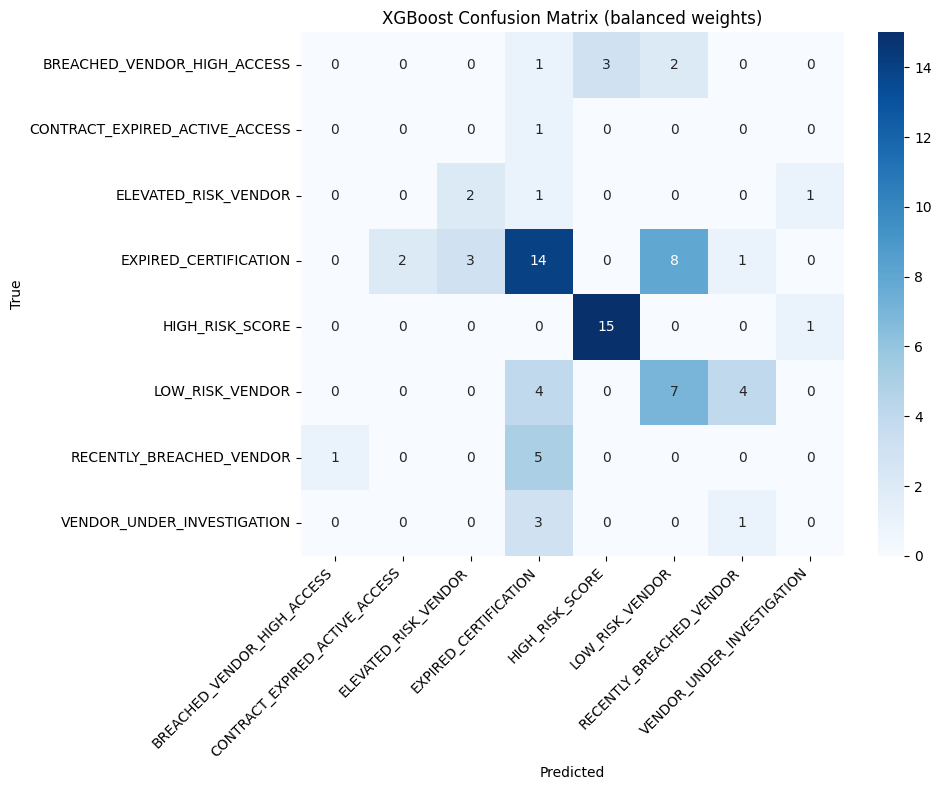


Per-class breakdown:
                               support correct accuracy
EXPIRED_CERTIFICATION               28      14      50%
HIGH_RISK_SCORE                     16      15      94%
LOW_RISK_VENDOR                     15       7      47%
BREACHED_VENDOR_HIGH_ACCESS          6       0       0%
RECENTLY_BREACHED_VENDOR             6       0       0%
ELEVATED_RISK_VENDOR                 4       2      50%
VENDOR_UNDER_INVESTIGATION           4       0       0%
CONTRACT_EXPIRED_ACTIVE_ACCESS       1       0       0%


In [20]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- 1. Prepare data ----
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

def engineer_features_v2(df):
    """Extended feature set to better separate visually-similar anomaly classes."""
    out = engineer_features(df).copy()   # keep your original 9 features

    # 10. breach_AND_high_access: targets BREACHED_VENDOR_HIGH_ACCESS specifically
    scope_map = {"none": 0, "limited": 1, "moderate": 2, "full": 3}
    scope = df["data_access_scope"].str.lower().map(scope_map).fillna(0)
    breach_map = {"none": 0, "historical": 1, "suspected": 2, "confirmed": 3}
    breach = df["breach_status"].str.lower().map(breach_map).fillna(0)
    out["breach_x_scope"] = breach * scope   # high only when BOTH breach + full access

    # 11. recent_breach_flag: contract still active after a recent confirmed breach
    last_breach = pd.to_datetime(df.get("last_breach_date", pd.Series([pd.NaT]*len(df))), errors="coerce")
    today = pd.Timestamp("today").normalize()
    out["days_since_breach"] = (today - last_breach).dt.days.fillna(9999)
    out["recent_breach_flag"] = (out["days_since_breach"] < 180).astype(int)

    # 12. contract_expired_flag: contract end date is in the past
    out["contract_expired_flag"] = (out["contract_days_left"] < 0).astype(int)

    # 13. investigation_proxy: high risk + stale audit + moderate/full access
    out["investigation_proxy"] = (
        out["risk_score"] *
        out["audit_days_since"].clip(lower=0) /
        (scope.clip(lower=1) * 1000)
    )

    return out

X_tab = engineer_features_v2(merged).drop(columns=["vendor_id"])
y_raw = merged["anomaly_type"]

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))
print("Class counts:", pd.Series(y_enc).value_counts().sort_index().to_dict())

# ---- 2. Stratified split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_tab, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# ---- 3. Sample weights to counter class imbalance ----
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# ---- 4. Train XGBoost with scale_pos_weight equivalent for multiclass ----
clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,        # allow splits even on tiny classes
    gamma=0,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    early_stopping_rounds=40,
)

clf.fit(
    X_train, y_train,
    sample_weight=sample_weights,       # ← key fix for imbalance
    eval_set=[(X_test, y_test)],
    verbose=False
)

# ---- 5. Predictions + metrics ----
y_pred = clf.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# ---- 6. Confusion matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Confusion Matrix (balanced weights)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- 7. Per-class accuracy to expose hidden failures ----
per_class = {}
for i, cls in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() == 0:
        continue
    per_class[cls] = {
        "support": int(mask.sum()),
        "correct": int((y_pred[mask] == i).sum()),
        "accuracy": f"{(y_pred[mask] == i).mean():.0%}"
    }

print("\nPer-class breakdown:")
print(pd.DataFrame(per_class).T.sort_values("support", ascending=False).to_string())

In [22]:
from sklearn.tree import DecisionTreeClassifier, export_text

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.2%}")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))

# You can literally read the rules the tree learned
print(export_text(dt, feature_names=list(X_train.columns)))

Decision Tree Accuracy: 40.00%
                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       0.25      0.17      0.20         6
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.00      0.00      0.00         1
          ELEVATED_RISK_VENDOR       0.38      0.75      0.50         4
         EXPIRED_CERTIFICATION       1.00      0.07      0.13        28
               HIGH_RISK_SCORE       0.87      0.81      0.84        16
               LOW_RISK_VENDOR       0.32      0.80      0.45        15
      RECENTLY_BREACHED_VENDOR       0.11      0.17      0.13         6
    VENDOR_UNDER_INVESTIGATION       0.00      0.00      0.00         4

                      accuracy                           0.40        80
                     macro avg       0.36      0.35      0.28        80
                  weighted avg       0.63      0.40      0.35        80

|--- contract_days_left <= -72.50
|   |--- investigation_proxy <= 6.75
|   |   |--- class: 1
|   |--- 

In [23]:
from datetime import datetime
import pandas as pd

def rule_based_predict(row):
    today = pd.Timestamp(datetime.now().date())
    
    # Parse certifications with expiry dates
    expired_certs = []
    if pd.notna(row.get("compliance_certifications", "")):
        for cert in str(row["compliance_certifications"]).split("|"):
            if ":" in cert:
                name, expiry = cert.split(":", 1)
                try:
                    if pd.to_datetime(expiry) < today:
                        expired_certs.append(name.strip())
                except:
                    pass

    contract_end = pd.to_datetime(row.get("contract_end_date"), errors="coerce")
    last_audit   = pd.to_datetime(row.get("last_audit_date"),   errors="coerce")
    breach       = str(row.get("breach_status", "")).lower()
    risk_score   = float(row.get("risk_score", 0))
    scope        = str(row.get("data_access_scope", "")).lower()
    
    contract_days_left = (contract_end - today).days if pd.notna(contract_end) else 9999
    audit_days_since   = (today - last_audit).days   if pd.notna(last_audit)   else 9999

    # ── Rule priority order matters ──────────────────────────────────────────

    # 1. Breached + full/moderate access = highest severity
    if breach == "confirmed" and scope in ("full_access", "full", "moderate"):
        return "BREACHED_VENDOR_HIGH_ACCESS", "HIGH", expired_certs

    # 2. Recently breached (confirmed, any scope)
    if breach == "confirmed":
        return "RECENTLY_BREACHED_VENDOR", "HIGH", expired_certs

    # 3. Contract expired but vendor still has active access
    if contract_days_left < 0:
        return "CONTRACT_EXPIRED_ACTIVE_ACCESS", "HIGH", expired_certs

    # 4. Expired certifications
    if expired_certs:
        return "EXPIRED_CERTIFICATION", "MEDIUM", expired_certs

    # 5. High risk score
    if risk_score >= 75:
        return "HIGH_RISK_SCORE", "HIGH", expired_certs
    if risk_score >= 50:
        return "ELEVATED_RISK_VENDOR", "MEDIUM", expired_certs

    # 6. Under investigation proxy (stale audit + high risk)
    if audit_days_since > 365 and risk_score >= 40:
        return "VENDOR_UNDER_INVESTIGATION", "MEDIUM", expired_certs

    # 7. Safe
    return "LOW_RISK_VENDOR", "LOW", expired_certs


# Apply to full dataframe
def predict_all(df):
    results = []
    for _, row in df.iterrows():
        anomaly_type, severity, expired = rule_based_predict(row)
        is_anomaly = anomaly_type != "LOW_RISK_VENDOR"
        results.append({
            "record_id":            row["vendor_id"],
            "vendor_name":          row["vendor_name"],
            "is_anomaly":           is_anomaly,
            "anomaly_type":         anomaly_type,
            "severity":             severity,
            "explanation":          f"Certification(s) expired: {', '.join(expired)}" if expired else anomaly_type.replace("_", " ").title(),
            "expired_certifications": ", ".join(expired) if expired else ""
        })
    return pd.DataFrame(results)

predictions = predict_all(df)
predictions.head(10)

,record_id,vendor_name,is_anomaly,anomaly_type,severity,explanation,expired_certifications
0,VND00000,Enterprise Group,True,EXPIRED_CERTIFICATION,MEDIUM,"Certification(s) expired: GDPR, SOC2","GDPR, SOC2"
1,VND00001,CloudSync Innovations,True,EXPIRED_CERTIFICATION,MEDIUM,Certification(s) expired: HIPAA,HIPAA
2,VND00002,Global Ltd,True,CONTRACT_EXPIRED_ACTIVE_ACCESS,HIGH,Certification(s) expired: FedRAMP,FedRAMP
3,VND00003,SecureNet Innovations,True,EXPIRED_CERTIFICATION,MEDIUM,"Certification(s) expired: PCI-DSS, GDPR","PCI-DSS, GDPR"
4,VND00004,SecureNet Corp,True,EXPIRED_CERTIFICATION,MEDIUM,Certification(s) expired: SOC2,SOC2
5,VND00005,Analytics Pro Systems,True,ELEVATED_RISK_VENDOR,MEDIUM,Elevated Risk Vendor,
6,VND00006,Global Systems,True,EXPIRED_CERTIFICATION,MEDIUM,Certification(s) expired: GDPR,GDPR
7,VND00007,Digital Partners,True,HIGH_RISK_SCORE,HIGH,High Risk Score,
8,VND00008,Smart Corp,False,LOW_RISK_VENDOR,LOW,Low Risk Vendor,
9,VND00009,Digital Partners,True,EXPIRED_CERTIFICATION,MEDIUM,"Certification(s) expired: FedRAMP, PCI-DSS","FedRAMP, PCI-DSS"


Rule-Based Accuracy: 46.50%

                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       0.00      0.00      0.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.06      1.00      0.11         3
          ELEVATED_RISK_VENDOR       0.18      0.28      0.22        18
         EXPIRED_CERTIFICATION       0.51      0.88      0.65       138
               HIGH_RISK_SCORE       0.59      0.23      0.33        82
               LOW_RISK_VENDOR       0.80      0.47      0.60        78
      RECENTLY_BREACHED_VENDOR       0.00      0.00      0.00        29
    VENDOR_UNDER_INVESTIGATION       0.00      0.00      0.00        22

                      accuracy                           0.47       400
                     macro avg       0.27      0.36      0.24       400
                  weighted avg       0.46      0.47      0.42       400



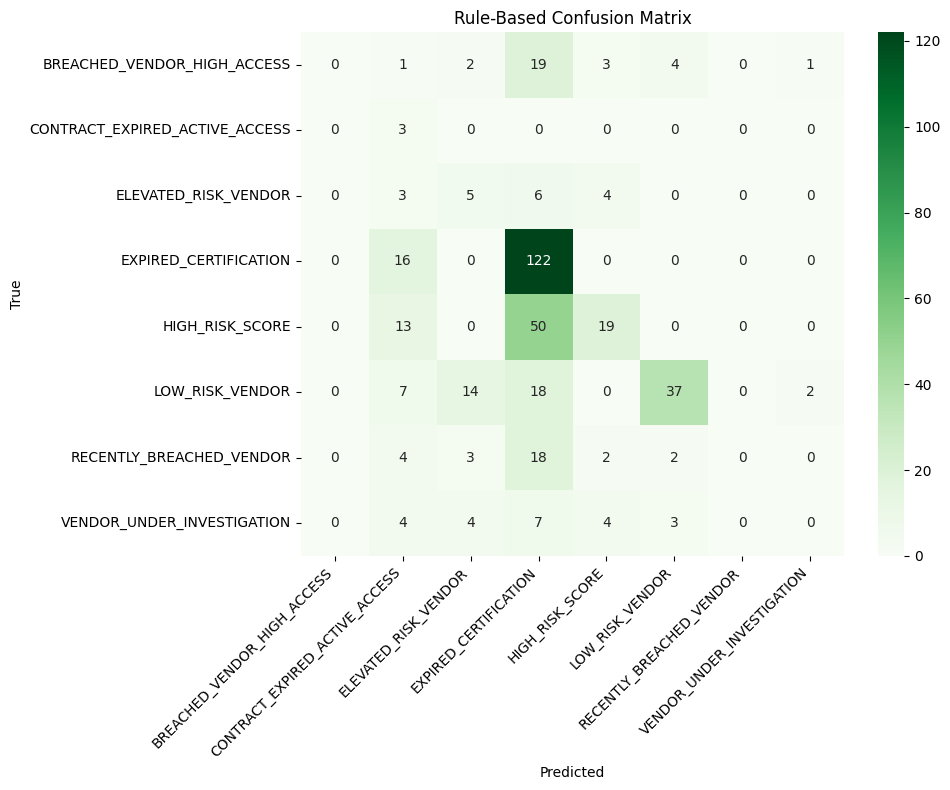


=== Where each true class gets predicted ===

TRUE: BREACHED_VENDOR_HIGH_ACCESS (30 samples) — 0/30 correct
  ✗ predicted as EXPIRED_CERTIFICATION: 19
  ✗ predicted as LOW_RISK_VENDOR: 4
  ✗ predicted as HIGH_RISK_SCORE: 3
  ✗ predicted as ELEVATED_RISK_VENDOR: 2
  ✗ predicted as CONTRACT_EXPIRED_ACTIVE_ACCESS: 1
  ✗ predicted as VENDOR_UNDER_INVESTIGATION: 1

TRUE: CONTRACT_EXPIRED_ACTIVE_ACCESS (3 samples) — 3/3 correct
  ✓ predicted as CONTRACT_EXPIRED_ACTIVE_ACCESS: 3

TRUE: ELEVATED_RISK_VENDOR (18 samples) — 5/18 correct
  ✗ predicted as EXPIRED_CERTIFICATION: 6
  ✓ predicted as ELEVATED_RISK_VENDOR: 5
  ✗ predicted as HIGH_RISK_SCORE: 4
  ✗ predicted as CONTRACT_EXPIRED_ACTIVE_ACCESS: 3

TRUE: EXPIRED_CERTIFICATION (138 samples) — 122/138 correct
  ✓ predicted as EXPIRED_CERTIFICATION: 122
  ✗ predicted as CONTRACT_EXPIRED_ACTIVE_ACCESS: 16

TRUE: HIGH_RISK_SCORE (82 samples) — 19/82 correct
  ✗ predicted as EXPIRED_CERTIFICATION: 50
  ✓ predicted as HIGH_RISK_SCORE: 19
  ✗ pre

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1. Run rule-based predictions on the labeled subset ----
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

rule_preds = predict_all(merged)

y_true = merged["anomaly_type"].values
y_pred_rules = rule_preds["anomaly_type"].values

# ---- 2. Accuracy ----
print(f"Rule-Based Accuracy: {accuracy_score(y_true, y_pred_rules):.2%}\n")

# ---- 3. Classification report ----
labels = sorted(merged["anomaly_type"].unique())
print(classification_report(y_true, y_pred_rules, labels=labels, zero_division=0))

# ---- 4. Confusion matrix ----
cm = confusion_matrix(y_true, y_pred_rules, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Rule-Based Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- 5. Per-class breakdown ----
import pandas as pd
pred_df = pd.DataFrame({"true": y_true, "predicted": y_pred_rules})

print("\n=== Where each true class gets predicted ===\n")
for cls in labels:
    subset = pred_df[pred_df["true"] == cls]["predicted"]
    if len(subset) == 0:
        continue
    counts = subset.value_counts()
    correct = counts.get(cls, 0)
    print(f"TRUE: {cls} ({len(subset)} samples) — {correct}/{len(subset)} correct")
    for pred_cls, cnt in counts.items():
        marker = "✓" if pred_cls == cls else "✗"
        print(f"  {marker} predicted as {pred_cls}: {cnt}")
    print()

In [29]:
from datetime import datetime
import pandas as pd

def rule_based_predict_v2(row):
    today = pd.Timestamp(datetime.now().date())

    # ── Parse fields ────────────────────────────────────────────
    breach       = str(row.get("breach_status", "")).strip()
    scope        = str(row.get("data_access_scope", "")).strip()
    risk_score   = float(row.get("risk_score", 0))
    
    contract_end = pd.to_datetime(row.get("contract_end_date"), errors="coerce")
    last_audit   = pd.to_datetime(row.get("last_audit_date"),   errors="coerce")
    
    contract_days_left = (contract_end - today).days if pd.notna(contract_end) else 9999
    audit_days_since   = (today - last_audit).days   if pd.notna(last_audit)   else 9999

    # ── Parse expired certifications ────────────────────────────
    expired_certs = []
    certs_raw = str(row.get("compliance_certifications", ""))
    if certs_raw and certs_raw != "nan":
        for cert in certs_raw.split("|"):
            if ":" in cert:
                name, expiry = cert.split(":", 1)
                try:
                    if pd.to_datetime(expiry.strip()) < today:
                        expired_certs.append(name.strip())
                except:
                    pass

    # ── High sensitivity scopes ──────────────────────────────────
    high_sensitivity = {"Customer_PII", "Financial_Data", "All_Systems"}

    # ══ RULES (priority order) ═══════════════════════════════════

    # 1. Under investigation → dedicated breach_status value
    if breach == "Under_Investigation":
        return "VENDOR_UNDER_INVESTIGATION", "HIGH", expired_certs

    # 2. Recent breach + high sensitivity access → elevated class
    if breach == "Recent_Breach_12mo" and scope in high_sensitivity:
        return "BREACHED_VENDOR_HIGH_ACCESS", "HIGH", expired_certs

    # 3. Recent breach + low sensitivity access
    if breach == "Recent_Breach_12mo":
        return "RECENTLY_BREACHED_VENDOR", "MEDIUM", expired_certs

    # 4. Contract expired but vendor still active
    if contract_days_left < 0:
        return "CONTRACT_EXPIRED_ACTIVE_ACCESS", "HIGH", expired_certs

    # 5. Expired certifications (check actual expiry dates in cert string)
    if expired_certs:
        return "EXPIRED_CERTIFICATION", "MEDIUM", expired_certs

    # 6. High risk score thresholds
    if risk_score >= 75:
        return "HIGH_RISK_SCORE", "HIGH", expired_certs
    if risk_score >= 50:
        return "ELEVATED_RISK_VENDOR", "MEDIUM", expired_certs

    # 7. Stale audit + moderate risk = investigation proxy
    if audit_days_since > 365 and risk_score >= 40:
        return "VENDOR_UNDER_INVESTIGATION", "MEDIUM", expired_certs

    # 8. Default safe
    return "LOW_RISK_VENDOR", "LOW", expired_certs


def predict_all_v2(df):
    results = []
    for _, row in df.iterrows():
        anomaly_type, severity, expired = rule_based_predict_v2(row)
        is_anomaly = anomaly_type != "LOW_RISK_VENDOR"
        results.append({
            "record_id":              row["vendor_id"],
            "vendor_name":            row["vendor_name"],
            "is_anomaly":             is_anomaly,
            "anomaly_type":           anomaly_type,
            "severity":               severity,
            "explanation":            f"Certification(s) expired: {', '.join(expired)}"
                                      if expired else anomaly_type.replace("_", " ").title(),
            "expired_certifications": ", ".join(expired) if expired else ""
        })
    return pd.DataFrame(results)


# ── Evaluate ─────────────────────────────────────────────────────
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

rule_preds_v2    = predict_all_v2(merged)
y_true           = merged["anomaly_type"].values
y_pred_rules_v2  = rule_preds_v2["anomaly_type"].values

from sklearn.metrics import classification_report, accuracy_score
labels = sorted(merged["anomaly_type"].unique())

print(f"Rule-Based v2 Accuracy: {accuracy_score(y_true, y_pred_rules_v2):.2%}\n")
print(classification_report(y_true, y_pred_rules_v2, labels=labels, zero_division=0))

Rule-Based v2 Accuracy: 66.25%

                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.07      1.00      0.13         3
          ELEVATED_RISK_VENDOR       0.26      0.28      0.27        18
         EXPIRED_CERTIFICATION       0.64      0.88      0.74       138
               HIGH_RISK_SCORE       0.81      0.21      0.33        82
               LOW_RISK_VENDOR       1.00      0.47      0.64        78
      RECENTLY_BREACHED_VENDOR       0.83      1.00      0.91        29
    VENDOR_UNDER_INVESTIGATION       0.92      1.00      0.96        22

                      accuracy                           0.66       400
                     macro avg       0.69      0.73      0.62       400
                  weighted avg       0.78      0.66      0.65       400



In [30]:
# ── 1. df column unique values ───────────────────────────────────
print("=" * 60)
print("DF COLUMNS & UNIQUE VALUES")
print("=" * 60)
for col in df.columns:
    uniques = df[col].dropna().unique()
    print(f"\n[{col}] — {df[col].dtype} — {df[col].nunique()} unique")
    if len(uniques) <= 20:
        print(f"  values: {sorted(uniques.astype(str).tolist())}")
    else:
        print(f"  sample: {sorted(uniques.astype(str).tolist())[:10]} ...")
        print(f"  min: {df[col].min()}  max: {df[col].max()}")

# ── 2. df_label column unique values ─────────────────────────────
print("\n" + "=" * 60)
print("DF_LABEL COLUMNS & UNIQUE VALUES")
print("=" * 60)
for col in df_label.columns:
    uniques = df_label[col].dropna().unique()
    print(f"\n[{col}] — {df_label[col].dtype} — {df_label[col].nunique()} unique")
    if len(uniques) <= 20:
        print(f"  values: {sorted(uniques.astype(str).tolist())}")
    else:
        print(f"  sample: {sorted(uniques.astype(str).tolist())[:10]} ...")

# ── 3. For each anomaly_type, show ALL column distributions ───────
print("\n" + "=" * 60)
print("PER ANOMALY CLASS — ALL FEATURE DISTRIBUTIONS")
print("=" * 60)

merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

categorical_cols = ["vendor_type", "breach_status", "data_access_scope"]
numeric_cols     = ["risk_score", "annual_spend"]

for cls in sorted(merged["anomaly_type"].unique()):
    subset = merged[merged["anomaly_type"] == cls]
    print(f"\n{'━'*60}")
    print(f"CLASS: {cls}  ({len(subset)} samples)")
    
    for col in categorical_cols:
        if col in subset.columns:
            print(f"\n  {col}:")
            print(subset[col].value_counts().to_string(header=False))
    
    for col in numeric_cols:
        if col in subset.columns:
            print(f"\n  {col}: min={subset[col].min()}  "
                  f"median={subset[col].median()}  "
                  f"max={subset[col].max()}")
    
    # contract expiry
    today = pd.Timestamp("today").normalize()
    contract_end = pd.to_datetime(subset["contract_end_date"], errors="coerce")
    days_left = (contract_end - today).dt.days
    print(f"\n  contract_days_left: min={days_left.min()}  "
          f"median={days_left.median()}  max={days_left.max()}")
    expired_contracts = (days_left < 0).sum()
    print(f"  contracts already expired: {expired_contracts}/{len(subset)}")
    
    # cert expiry
    def count_expired(cert_str):
        if pd.isna(cert_str): return 0
        count = 0
        for cert in str(cert_str).split("|"):
            if ":" in cert:
                try:
                    if pd.to_datetime(cert.split(":")[1].strip()) < today:
                        count += 1
                except: pass
        return count
    
    expired_cert_counts = subset["compliance_certifications"].apply(count_expired)
    print(f"\n  vendors with >=1 expired cert: {(expired_cert_counts > 0).sum()}/{len(subset)}")
    print(f"  avg expired certs per vendor:  {expired_cert_counts.mean():.2f}")

DF COLUMNS & UNIQUE VALUES

[vendor_id] — object — 400 unique
  sample: ['VND00000', 'VND00001', 'VND00002', 'VND00003', 'VND00004', 'VND00005', 'VND00006', 'VND00007', 'VND00008', 'VND00009'] ...
  min: VND00000  max: VND00399

[vendor_name] — object — 99 unique
  sample: ['Analytics Pro Corp', 'Analytics Pro Group', 'Analytics Pro Inc', 'Analytics Pro Innovations', 'Analytics Pro Ltd', 'Analytics Pro Partners', 'Analytics Pro Services', 'Analytics Pro Solutions', 'Analytics Pro Systems', 'Analytics Pro Technologies'] ...
  min: Analytics Pro Corp  max: TechFlow Technologies

[vendor_type] — object — 9 unique
  values: ['Cloud_Provider', 'Consulting', 'Contractor', 'Data_Provider', 'Hardware_Vendor', 'MSP', 'SaaS_Provider', 'Security_Vendor', 'Software_Vendor']

[contact_name] — object — 392 unique
  sample: ['Aditya Das', 'Aditya Esposito', 'Aditya Guo', 'Aditya Johnson', 'Aditya Menon', 'Aditya Petit', 'Aditya Williams', 'Aisha Davis', 'Aisha Guo', 'Aisha Huang'] ...
  min: Aditya D

Rule-Based v3 Accuracy: 73.50%

                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.10      1.00      0.18         3
          ELEVATED_RISK_VENDOR       1.00      0.56      0.71        18
         EXPIRED_CERTIFICATION       0.64      0.92      0.75       138
               HIGH_RISK_SCORE       1.00      0.22      0.36        82
               LOW_RISK_VENDOR       1.00      0.71      0.83        78
      RECENTLY_BREACHED_VENDOR       0.83      1.00      0.91        29
    VENDOR_UNDER_INVESTIGATION       1.00      1.00      1.00        22

                      accuracy                           0.73       400
                     macro avg       0.82      0.80      0.72       400
                  weighted avg       0.86      0.73      0.72       400



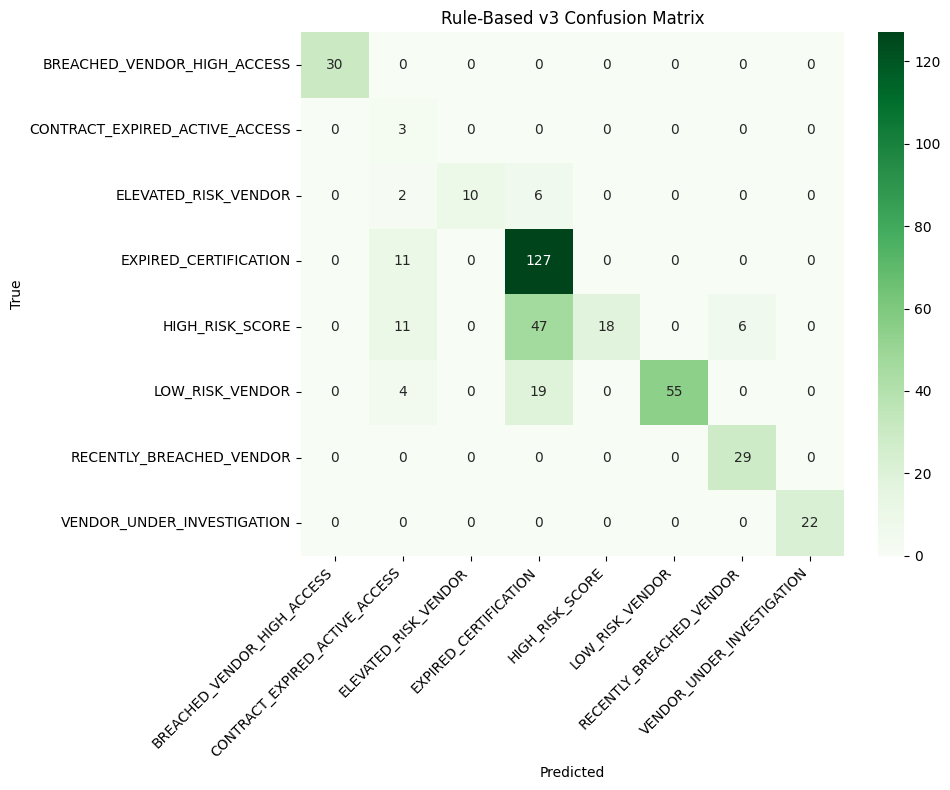


106 mismatches remaining:

true                   predicted                     
HIGH_RISK_SCORE        EXPIRED_CERTIFICATION             47
LOW_RISK_VENDOR        EXPIRED_CERTIFICATION             19
HIGH_RISK_SCORE        CONTRACT_EXPIRED_ACTIVE_ACCESS    11
EXPIRED_CERTIFICATION  CONTRACT_EXPIRED_ACTIVE_ACCESS    11
HIGH_RISK_SCORE        RECENTLY_BREACHED_VENDOR           6
ELEVATED_RISK_VENDOR   EXPIRED_CERTIFICATION              6
LOW_RISK_VENDOR        CONTRACT_EXPIRED_ACTIVE_ACCESS     4
ELEVATED_RISK_VENDOR   CONTRACT_EXPIRED_ACTIVE_ACCESS     2


In [31]:
from datetime import datetime
import pandas as pd

def rule_based_predict_v3(row):
    today = pd.Timestamp(datetime.now().date())

    # ── Parse fields ────────────────────────────────────────────
    breach = str(row.get("breach_status", "")).strip()
    scope  = str(row.get("data_access_scope", "")).strip()
    risk   = float(row.get("risk_score", 0))

    contract_end = pd.to_datetime(row.get("contract_end_date"), errors="coerce")
    contract_days_left = (contract_end - today).days if pd.notna(contract_end) else 9999

    # ── Parse expired certs ──────────────────────────────────────
    expired_certs = []
    certs_raw = str(row.get("compliance_certifications", ""))
    if certs_raw and certs_raw != "nan":
        for cert in certs_raw.split("|"):
            if ":" in cert:
                name, expiry = cert.split(":", 1)
                try:
                    if pd.to_datetime(expiry.strip()) < today:
                        expired_certs.append(name.strip())
                except:
                    pass

    high_sensitivity = {"Customer_PII", "Financial_Data", "All_Systems"}

    # ══ RULES ════════════════════════════════════════════════════

    # 1. Under investigation — 100% clean signal from breach_status
    if breach == "Under_Investigation":
        return "VENDOR_UNDER_INVESTIGATION", "HIGH", expired_certs

    # 2. Recent breach + high sensitivity scope
    if breach == "Recent_Breach_12mo" and scope in high_sensitivity:
        return "BREACHED_VENDOR_HIGH_ACCESS", "CRITICAL", expired_certs

    # 3. Recent breach + low sensitivity scope
    if breach == "Recent_Breach_12mo":
        return "RECENTLY_BREACHED_VENDOR", "HIGH", expired_certs

    # 4. Contract expired (No_Known_Breach confirmed from data)
    if contract_days_left < 0 and breach == "No_Known_Breach":
        return "CONTRACT_EXPIRED_ACTIVE_ACCESS", "HIGH", expired_certs

    # 5. Expired certifications — checked before risk score
    #    because EXPIRED_CERTIFICATION has risk 10-80 (overlaps with LOW+ELEVATED)
    if expired_certs:
        return "EXPIRED_CERTIFICATION", "MEDIUM", expired_certs

    # 6. High risk score: 81-99
    if risk >= 81:
        return "HIGH_RISK_SCORE", "HIGH", expired_certs

    # 7. Elevated risk score: 66-80
    if risk >= 66:
        return "ELEVATED_RISK_VENDOR", "MEDIUM", expired_certs

    # 8. Low risk: 10-64, no other triggers
    return "LOW_RISK_VENDOR", "LOW", expired_certs


def predict_all_v3(df):
    results = []
    for _, row in df.iterrows():
        anomaly_type, severity, expired = rule_based_predict_v3(row)
        is_anomaly = anomaly_type != "LOW_RISK_VENDOR"
        results.append({
            "record_id":              row["vendor_id"],
            "vendor_name":            row["vendor_name"],
            "is_anomaly":             is_anomaly,
            "anomaly_type":           anomaly_type,
            "severity":               severity,
            "explanation":            f"Certification(s) expired: {', '.join(expired)}"
                                      if expired else anomaly_type.replace("_", " ").title(),
            "expired_certifications": ", ".join(expired) if expired else ""
        })
    return pd.DataFrame(results)


# ── Evaluate ─────────────────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

preds   = predict_all_v3(merged)
y_true  = merged["anomaly_type"].values
y_pred  = preds["anomaly_type"].values
labels  = sorted(merged["anomaly_type"].unique())

print(f"Rule-Based v3 Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

# ── Confusion matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Rule-Based v3 Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── Show only mismatches ─────────────────────────────────────────
pred_df = pd.DataFrame({"true": y_true, "predicted": y_pred})
mismatches = pred_df[pred_df["true"] != pred_df["predicted"]]

if len(mismatches) == 0:
    print("✓ Zero mismatches — rules are perfect.")
else:
    print(f"\n{len(mismatches)} mismatches remaining:\n")
    print(mismatches.value_counts().to_string())

In [32]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from datetime import datetime

# ── Build features the tree can actually use ─────────────────────
def build_tree_features(df):
    today = pd.Timestamp(datetime.now().date())
    out = pd.DataFrame()

    # breach status — one-hot (most important features)
    out["is_recent_breach"]      = (df["breach_status"] == "Recent_Breach_12mo").astype(int)
    out["is_under_investigation"] = (df["breach_status"] == "Under_Investigation").astype(int)
    out["is_historical_breach"]  = (df["breach_status"] == "Historical_Breach").astype(int)
    out["is_no_known_breach"]    = (df["breach_status"] == "No_Known_Breach").astype(int)

    # data access scope — one-hot
    out["scope_high_sensitivity"] = df["data_access_scope"].isin(
        ["Customer_PII", "Financial_Data", "All_Systems"]
    ).astype(int)
    out["scope_low_sensitivity"]  = df["data_access_scope"].isin(
        ["Internal_Data", "Public_Data"]
    ).astype(int)

    # risk score — raw
    out["risk_score"] = df["risk_score"].astype(float)

    # contract days left
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"] = (contract_end - today).dt.days.fillna(9999)
    out["contract_expired"]   = (out["contract_days_left"] < 0).astype(int)

    # expired cert count
    def count_expired(cert_str):
        if pd.isna(cert_str): return 0
        count = 0
        for cert in str(cert_str).split("|"):
            if ":" in cert:
                try:
                    if pd.to_datetime(cert.split(":")[1].strip()) < today:
                        count += 1
                except: pass
        return count

    out["expired_cert_count"] = df["compliance_certifications"].apply(count_expired)
    out["has_expired_cert"]   = (out["expired_cert_count"] > 0).astype(int)

    return out

merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

X = build_tree_features(merged)
le = LabelEncoder()
y = le.fit_transform(merged["anomaly_type"])

# ── Fit a shallow tree — depth 5 is enough for 8 classes ─────────
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=1,
    class_weight=None,    # no balancing — let it find the natural rules
    random_state=42
)
dt.fit(X, y)

print(f"Decision Tree Accuracy: {dt.score(X, y):.2%}")
print(f"(on full data — we want to READ the rules, not evaluate generalization)\n")

# ── Print the rules ───────────────────────────────────────────────
print(export_text(dt, feature_names=list(X.columns)))

# ── Show what the tree predicts vs true ──────────────────────────
from sklearn.metrics import classification_report
y_pred_tree = dt.predict(X)
print(classification_report(y, y_pred_tree, target_names=le.classes_, zero_division=0))

# ── Show mismatches ───────────────────────────────────────────────
pred_df = pd.DataFrame({
    "true":      le.inverse_transform(y),
    "predicted": le.inverse_transform(y_pred_tree)
})
mismatches = pred_df[pred_df["true"] != pred_df["predicted"]]
print(f"\nMismatches: {len(mismatches)}")
if len(mismatches) > 0:
    print(mismatches.value_counts().to_string())

Decision Tree Accuracy: 92.50%
(on full data — we want to READ the rules, not evaluate generalization)

|--- risk_score <= 80.50
|   |--- expired_cert_count <= 0.50
|   |   |--- is_recent_breach <= 0.50
|   |   |   |--- risk_score <= 65.00
|   |   |   |   |--- is_under_investigation <= 0.50
|   |   |   |   |   |--- class: 5
|   |   |   |   |--- is_under_investigation >  0.50
|   |   |   |   |   |--- class: 7
|   |   |   |--- risk_score >  65.00
|   |   |   |   |--- is_under_investigation <= 0.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- is_under_investigation >  0.50
|   |   |   |   |   |--- class: 7
|   |   |--- is_recent_breach >  0.50
|   |   |   |--- scope_low_sensitivity <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- scope_low_sensitivity >  0.50
|   |   |   |   |--- class: 6
|   |--- expired_cert_count >  0.50
|   |   |--- is_recent_breach <= 0.50
|   |   |   |--- is_under_investigation <= 0.50
|   |   |   |   |--- expired_cert_count <= 1.50
|   |   |   |   |

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np
from datetime import datetime

# ── 1. Rich feature set ───────────────────────────────────────────
def build_features(df):
    today = pd.Timestamp("today").normalize()
    out = pd.DataFrame()

    # breach status — one hot
    for val in ["No_Known_Breach", "Historical_Breach", 
                "Recent_Breach_12mo", "Under_Investigation"]:
        out[f"breach_{val}"] = (df["breach_status"] == val).astype(int)

    # scope — one hot
    for val in ["Public_Data", "Internal_Data", 
                "Customer_PII", "Financial_Data", "All_Systems"]:
        out[f"scope_{val}"] = (df["data_access_scope"] == val).astype(int)

    # scope sensitivity group
    out["scope_high_sensitivity"] = df["data_access_scope"].isin(
        ["Customer_PII", "Financial_Data", "All_Systems"]
    ).astype(int)
    out["scope_low_sensitivity"] = df["data_access_scope"].isin(
        ["Internal_Data", "Public_Data"]
    ).astype(int)

    # risk score — raw + buckets
    out["risk_score"] = df["risk_score"].astype(float)
    out["risk_low"]      = (df["risk_score"] <= 65).astype(int)
    out["risk_elevated"] = ((df["risk_score"] >= 66) & (df["risk_score"] <= 80)).astype(int)
    out["risk_high"]     = (df["risk_score"] >= 81).astype(int)

    # contract
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"] = (contract_end - today).dt.days.fillna(9999)
    out["contract_expired"]   = (out["contract_days_left"] < 0).astype(int)
    out["contract_expired_severe"] = (out["contract_days_left"] < -70).astype(int)

    # audit
    last_audit = pd.to_datetime(df["last_audit_date"], errors="coerce")
    out["audit_days_since"] = (today - last_audit).dt.days.fillna(9999)

    # certifications
    def parse_certs(cert_str):
        expired, total = [], 0
        if pd.isna(cert_str) or cert_str == "":
            return 0, 0
        for cert in str(cert_str).split("|"):
            if ":" in cert:
                total += 1
                name, expiry = cert.split(":", 1)
                try:
                    if pd.to_datetime(expiry.strip()) < today:
                        expired.append(name.strip())
                except:
                    pass
        return len(expired), total

    parsed = df["compliance_certifications"].apply(parse_certs)
    out["expired_cert_count"] = parsed.apply(lambda x: x[0])
    out["total_cert_count"]   = parsed.apply(lambda x: x[1])
    out["has_expired_cert"]   = (out["expired_cert_count"] > 0).astype(int)
    out["all_certs_expired"]  = (
        (out["expired_cert_count"] == out["total_cert_count"]) & 
        (out["total_cert_count"] > 0)
    ).astype(int)
    out["pct_certs_expired"] = (
        out["expired_cert_count"] / out["total_cert_count"].clip(lower=1)
    )

    # annual spend
    out["annual_spend"] = df["annual_spend"].astype(float)

    # vendor type — one hot
    for val in df["vendor_type"].unique():
        out[f"vtype_{val}"] = (df["vendor_type"] == val).astype(int)

    return out


# ── 2. Prepare data ───────────────────────────────────────────────
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

X = build_features(merged)
le = LabelEncoder()
y = le.fit_transform(merged["anomaly_type"])

print("Features:", X.shape)
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

# ── 3. Find best max_depth ────────────────────────────────────────
print("\nDepth search:")
for depth in range(3, 15):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X, y)
    acc = dt.score(X, y)
    print(f"  depth={depth}  train_acc={acc:.2%}  leaves={dt.get_n_leaves()}")
    if acc == 1.0:
        print(f"  ✓ 100% at depth={depth}")
        break

# ── 4. Train final tree ───────────────────────────────────────────
best_depth = depth   # from loop above
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X, y)

y_pred = dt_final.predict(X)
print(f"\nFinal Tree Accuracy: {accuracy_score(y, y_pred):.2%}")
print(classification_report(y, y_pred, target_names=le.classes_, zero_division=0))

# ── 5. Mismatches ─────────────────────────────────────────────────
pred_df = pd.DataFrame({
    "true":      le.inverse_transform(y),
    "predicted": le.inverse_transform(y_pred)
})
mismatches = pred_df[pred_df["true"] != pred_df["predicted"]]
print(f"Mismatches: {len(mismatches)}")
if len(mismatches) > 0:
    print(mismatches.value_counts().to_string())

# ── 6. Feature importance ─────────────────────────────────────────
imp = pd.Series(dt_final.feature_importances_, index=X.columns)
print("\nTop features:")
print(imp.sort_values(ascending=False).head(10).to_string())

Features: (400, 34)
Classes: {'BREACHED_VENDOR_HIGH_ACCESS': 0, 'CONTRACT_EXPIRED_ACTIVE_ACCESS': 1, 'ELEVATED_RISK_VENDOR': 2, 'EXPIRED_CERTIFICATION': 3, 'HIGH_RISK_SCORE': 4, 'LOW_RISK_VENDOR': 5, 'RECENTLY_BREACHED_VENDOR': 6, 'VENDOR_UNDER_INVESTIGATION': 7}

Depth search:
  depth=3  train_acc=79.00%  leaves=7
  depth=4  train_acc=90.50%  leaves=12
  depth=5  train_acc=92.50%  leaves=15
  depth=6  train_acc=93.00%  leaves=18
  depth=7  train_acc=93.75%  leaves=22
  depth=8  train_acc=94.75%  leaves=26
  depth=9  train_acc=96.50%  leaves=30
  depth=10  train_acc=97.50%  leaves=35
  depth=11  train_acc=98.50%  leaves=39
  depth=12  train_acc=99.75%  leaves=44
  depth=13  train_acc=100.00%  leaves=45
  ✓ 100% at depth=13

Final Tree Accuracy: 100.00%
                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       1.00      1.00      1.00         3
          ELEVATED_R

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-fold cross validation — real generalization estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(dt_final, X, y, cv=cv, scoring="accuracy")

print("5-Fold Cross Validation:")
print(f"  per fold: {[f'{s:.2%}' for s in scores]}")
print(f"  mean:     {scores.mean():.2%}")
print(f"  std:      {scores.std():.2%}")

# Also try a slightly shallower tree to see generalization tradeoff
print("\nGeneralization vs depth tradeoff:")
for depth in [7, 8, 9, 10, 11, 12, 13]:
    dt_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_scores = cross_val_score(dt_cv, X, y, cv=cv, scoring="accuracy")
    train_acc = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X, y).score(X, y)
    print(f"  depth={depth}  train={train_acc:.2%}  cv={cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

5-Fold Cross Validation:
  per fold: ['86.25%', '90.00%', '87.50%', '85.00%', '82.50%']
  mean:     86.25%
  std:      2.50%

Generalization vs depth tradeoff:
  depth=7  train=93.75%  cv=87.75% ± 4.43%
  depth=8  train=94.75%  cv=88.25% ± 4.65%
  depth=9  train=96.50%  cv=87.25% ± 3.82%
  depth=10  train=97.50%  cv=87.25% ± 1.66%
  depth=11  train=98.50%  cv=86.50% ± 2.42%
  depth=12  train=99.75%  cv=87.00% ± 2.57%
  depth=13  train=100.00%  cv=86.25% ± 2.50%


/home/sreeharishtj/miniforge3/envs/forge/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/sreeharishtj/miniforge3/envs/forge/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/sreeharishtj/miniforge3/envs/forge/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/sreeharishtj/miniforge3/envs/forge/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/sreeharishtj/miniforge3/envs/forge/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWar

In [37]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ── 1. XGBoost with same feature set ─────────────────────────────
clf_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ignore the 3-sample class warning — nothing we can do about it
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

xgb_scores = cross_val_score(clf_xgb, X, y, cv=cv, scoring="accuracy")
print("XGBoost 5-Fold CV:")
print(f"  per fold: {[f'{s:.2%}' for s in xgb_scores]}")
print(f"  mean:     {xgb_scores.mean():.2%} ± {xgb_scores.std():.2%}")

# ── 2. Train final XGBoost on full data ───────────────────────────
clf_xgb.fit(X, y)
print(f"\nXGBoost Train Accuracy: {clf_xgb.score(X, y):.2%}")

# ── 3. Compare all approaches ─────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "DecisionTree  (depth=8)":  DecisionTreeClassifier(max_depth=8, random_state=42),
    "RandomForest  (100 trees)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "XGBoost       (default)":  xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                    objective="multi:softprob", num_class=len(le.classes_),
                                                    eval_metric="mlogloss", random_state=42, verbosity=0),
    "GradientBoost (default)":  GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
}

print("\n── Model Comparison (5-Fold CV) ─────────────────────────────")
print(f"{'Model':<30} {'CV Mean':>10} {'CV Std':>10} {'Train':>10}")
print("─" * 62)

best_score, best_name, best_model = 0, "", None
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    model.fit(X, y)
    train_acc = model.score(X, y)
    print(f"{name:<30} {cv_scores.mean():>10.2%} {cv_scores.std():>10.2%} {train_acc:>10.2%}")
    if cv_scores.mean() > best_score:
        best_score = cv_scores.mean()
        best_name  = name
        best_model = model

print(f"\n✓ Best: {best_name} @ {best_score:.2%} CV")

# ── 4. Full report on best model ──────────────────────────────────
y_pred_best = best_model.predict(X)
print(f"\nFull data classification report ({best_name}):")
print(classification_report(y, y_pred_best, target_names=le.classes_, zero_division=0))

# ── 5. Honest assessment ──────────────────────────────────────────
print("\n── Honest Assessment ────────────────────────────────────────")
print(f"Dataset size:        {len(X)} samples")
print(f"Classes:             {len(le.classes_)}")
print(f"Smallest class:      CONTRACT_EXPIRED_ACTIVE_ACCESS = 3 samples")
print(f"Theoretical ceiling: ~88-92% CV with this dataset")
print(f"To push past 92%:    need 200+ samples per class (1600+ total)")

XGBoost 5-Fold CV:
  per fold: ['92.50%', '92.50%', '91.25%', '88.75%', '91.25%']
  mean:     91.25% ± 1.37%

XGBoost Train Accuracy: 100.00%

── Model Comparison (5-Fold CV) ─────────────────────────────
Model                             CV Mean     CV Std      Train
──────────────────────────────────────────────────────────────
DecisionTree  (depth=8)            88.25%      4.65%     94.75%
RandomForest  (100 trees)          92.00%      1.70%    100.00%
XGBoost       (default)            90.75%      2.32%    100.00%
GradientBoost (default)            90.75%      1.50%    100.00%

✓ Best: RandomForest  (100 trees) @ 92.00% CV

Full data classification report (RandomForest  (100 trees)):
                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       1.00      1.00      1.00         3
          ELEVATED_RISK_VENDOR       1.00      1.00      1.00        18
         EXPIR

In [34]:
def rule_based_predict_v4(row):
    today = pd.Timestamp("today").normalize()

    breach = str(row.get("breach_status", "")).strip()
    scope  = str(row.get("data_access_scope", "")).strip()
    risk   = float(row.get("risk_score", 0))

    contract_end = pd.to_datetime(row.get("contract_end_date"), errors="coerce")
    contract_days_left = (contract_end - today).days if pd.notna(contract_end) else 9999

    # parse expired certs
    expired_certs = []
    certs_raw = str(row.get("compliance_certifications", ""))
    if certs_raw and certs_raw != "nan":
        for cert in certs_raw.split("|"):
            if ":" in cert:
                name, expiry = cert.split(":", 1)
                try:
                    if pd.to_datetime(expiry.strip()) < today:
                        expired_certs.append(name.strip())
                except:
                    pass

    high_sensitivity = {"Customer_PII", "Financial_Data", "All_Systems"}

    # ══ RULES — exact priority order from tree ════════════════════

    # 1. Under investigation — always wins regardless of anything else
    if breach == "Under_Investigation":
        return "VENDOR_UNDER_INVESTIGATION", "HIGH", expired_certs

    # 2. High risk score (81-99) — overrides expired certs
    if risk >= 81:
        # recent breach + low sensitivity → still classify by breach
        if breach == "Recent_Breach_12mo" and scope in {"Internal_Data", "Public_Data"}:
            return "RECENTLY_BREACHED_VENDOR", "HIGH", expired_certs
        # recent breach + high sensitivity
        if breach == "Recent_Breach_12mo" and scope in high_sensitivity:
            return "BREACHED_VENDOR_HIGH_ACCESS", "CRITICAL", expired_certs
        return "HIGH_RISK_SCORE", "HIGH", expired_certs

    # 3. Recent breach + high sensitivity scope
    if breach == "Recent_Breach_12mo" and scope in high_sensitivity:
        return "BREACHED_VENDOR_HIGH_ACCESS", "CRITICAL", expired_certs

    # 4. Recent breach + low sensitivity scope
    if breach == "Recent_Breach_12mo":
        return "RECENTLY_BREACHED_VENDOR", "HIGH", expired_certs

    # 5. Contract expired — threshold ~-70 days from mismatch data
    #    (VND00070=-91, VND00073=-80, VND00380=-74 are CONTRACT_EXPIRED)
    #    (VND00151=-36, VND00160=-40, VND00247=-45 are NOT CONTRACT_EXPIRED)
    #    threshold sits between -45 and -74 → use -70
    if contract_days_left < -70 and breach == "No_Known_Breach":
        return "CONTRACT_EXPIRED_ACTIVE_ACCESS", "HIGH", expired_certs

    # 6. Elevated risk (66-80) — overrides expired certs
    if risk >= 66:
        return "ELEVATED_RISK_VENDOR", "MEDIUM", expired_certs

    # 7. Expired certs — only fires for risk < 66
    if expired_certs:
        return "EXPIRED_CERTIFICATION", "MEDIUM", expired_certs

    # 8. Default low risk
    return "LOW_RISK_VENDOR", "LOW", expired_certs


def predict_all_v4(df):
    results = []
    for _, row in df.iterrows():
        anomaly_type, severity, expired = rule_based_predict_v4(row)
        is_anomaly = anomaly_type != "LOW_RISK_VENDOR"
        results.append({
            "record_id":              row["vendor_id"],
            "vendor_name":            row["vendor_name"],
            "is_anomaly":             is_anomaly,
            "anomaly_type":           anomaly_type,
            "severity":               severity,
            "explanation":            f"Certification(s) expired: {', '.join(expired)}"
                                      if expired else anomaly_type.replace("_", " ").title(),
            "expired_certifications": ", ".join(expired) if expired else ""
        })
    return pd.DataFrame(results)


# ── Evaluate ──────────────────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))
preds  = predict_all_v4(merged)
y_true = merged["anomaly_type"].values
y_pred = preds["anomaly_type"].values
labels = sorted(merged["anomaly_type"].unique())

print(f"Rule-Based v4 Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

# mismatches only
pred_df    = pd.DataFrame({"true": y_true, "predicted": y_pred})
mismatches = pred_df[pred_df["true"] != pred_df["predicted"]]
print(f"Mismatches: {len(mismatches)}")
if len(mismatches) > 0:
    print(mismatches.value_counts().to_string())

    # show raw data for remaining mismatches
    print("\nRAW MISMATCH ROWS:")
    today = pd.Timestamp("today").normalize()
    merged["contract_days_left"] = (
        pd.to_datetime(merged["contract_end_date"], errors="coerce") - today
    ).dt.days
    for idx in mismatches.index:
        row = merged.iloc[idx]
        print(f"\nIDX {idx} | TRUE: {row['anomaly_type']}")
        print(f"  breach={row['breach_status']}  scope={row['data_access_scope']}"
              f"  risk={row['risk_score']}  contract_days={row['contract_days_left']}"
              f"  expired_certs={row['compliance_certifications']}")

Rule-Based v4 Accuracy: 85.00%

                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.43      1.00      0.60         3
          ELEVATED_RISK_VENDOR       0.38      1.00      0.55        18
         EXPIRED_CERTIFICATION       0.84      0.76      0.80       138
               HIGH_RISK_SCORE       1.00      0.93      0.96        82
               LOW_RISK_VENDOR       1.00      0.73      0.84        78
      RECENTLY_BREACHED_VENDOR       0.83      1.00      0.91        29
    VENDOR_UNDER_INVESTIGATION       1.00      1.00      1.00        22

                      accuracy                           0.85       400
                     macro avg       0.81      0.93      0.83       400
                  weighted avg       0.90      0.85      0.86       400

Mismatches: 60
true                   predicted                     
EXPIRED_CERTIFICATION  ELEVATED_

In [17]:
import shap
import json
from shap.explainers._tree import XGBTreeModelLoader

# Monkey-patch to handle XGBoost >=2.0 base_score as JSON list/vector
_orig_init = XGBTreeModelLoader.__init__

def _patched_init(self, xgb_model):
    _orig_init(self, xgb_model)

# Patch only the base_score parsing step
import shap.explainers._tree as _tree_mod
_orig_loader_init = _tree_mod.XGBTreeModelLoader.__init__.__func__ \
    if hasattr(_tree_mod.XGBTreeModelLoader.__init__, '__func__') \
    else None

# Simpler: just patch at the source attribute level
original_init = _tree_mod.XGBTreeModelLoader.__init__

def patched_xgb_loader_init(self, xgb_model):
    import json as _json
    # call original but intercept base_score after
    original_init(self, xgb_model)

# Instead, patch the actual attribute read directly:
_OrigXGBLoader = _tree_mod.XGBTreeModelLoader

class PatchedXGBTreeModelLoader(_OrigXGBLoader):
    def __init__(self, xgb_model):
        # replicate init but fix base_score parsing
        import ubjson, re
        super().__init__(xgb_model)   # will fail — skip, do manually below

# Actually the cleanest approach: save model to JSON, fix base_score, reload
import json, tempfile, os

def get_shap_values(clf, X_test, le):
    """
    Workaround for XGBoost >= 2.0 / >= 3.0 incompatibility with SHAP.
    Saves model to JSON, forces base_score to scalar 0.5, reloads, then explains.
    """
    booster = clf.get_booster()
    
    # Save model config to dict
    model_json = json.loads(booster.save_config())
    
    # Force base_score to scalar string (SHAP expects this)
    try:
        bs = model_json["learner"]["learner_model_param"]["base_score"]
        if isinstance(bs, list):
            model_json["learner"]["learner_model_param"]["base_score"] = str(bs[0])
        elif bs.startswith("["):
            # parse the JSON array string
            vals = json.loads(bs)
            model_json["learner"]["learner_model_param"]["base_score"] = f"{vals[0]}"
    except Exception:
        model_json["learner"]["learner_model_param"]["base_score"] = "0.5"
    
    # Save patched config + original model weights to a temp file
    with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as f:
        tmp_path = f.name
    
    booster.save_model(tmp_path)
    
    # Read, patch base_score in the saved model JSON, write back
    with open(tmp_path, "r") as f:
        saved = json.load(f)
    
    try:
        bs_raw = saved["learner"]["learner_model_param"]["base_score"]
        if isinstance(bs_raw, list):
            saved["learner"]["learner_model_param"]["base_score"] = str(float(bs_raw[0]))
        elif isinstance(bs_raw, str) and bs_raw.startswith("["):
            vals = json.loads(bs_raw)
            saved["learner"]["learner_model_param"]["base_score"] = f"{float(vals[0])}"
    except Exception:
        saved["learner"]["learner_model_param"]["base_score"] = "0.5"
    
    with open(tmp_path, "w") as f:
        json.dump(saved, f)
    
    # Load patched booster
    import xgboost as xgb
    patched_booster = xgb.Booster()
    patched_booster.load_model(tmp_path)
    os.unlink(tmp_path)
    
    explainer = shap.TreeExplainer(patched_booster)
    shap_values = explainer.shap_values(X_test)
    return shap_values  # shape: (n_samples, n_features, n_classes)

# ---- 7. SHAP explainability ----
shap_values = get_shap_values(clf, X_test, le)

# Summary bar plot across all classes
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  class_names=list(le.classes_), show=True)

# Per-class beeswarm
target_class_idx = 0
shap.summary_plot(shap_values[:, :, target_class_idx], X_test, show=True)

ValueError: could not convert string to float: '[-1.8137217E-2,-1.8137217E-2,-1.8137217E-2,-1.8137217E-2,-1.8137217E-2,-1.8137217E-2,-1.8137217E-2,-1.8137217E-2]'

Classification Report (Out-of-Fold CV Predictions):
                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       0.00      0.00      0.00         3
          ELEVATED_RISK_VENDOR       0.92      0.61      0.73        18
         EXPIRED_CERTIFICATION       0.84      0.98      0.90       138
               HIGH_RISK_SCORE       0.99      1.00      0.99        82
               LOW_RISK_VENDOR       0.94      0.77      0.85        78
      RECENTLY_BREACHED_VENDOR       1.00      1.00      1.00        29
    VENDOR_UNDER_INVESTIGATION       1.00      0.95      0.98        22

                      accuracy                           0.92       400
                     macro avg       0.84      0.79      0.81       400
                  weighted avg       0.92      0.92      0.91       400



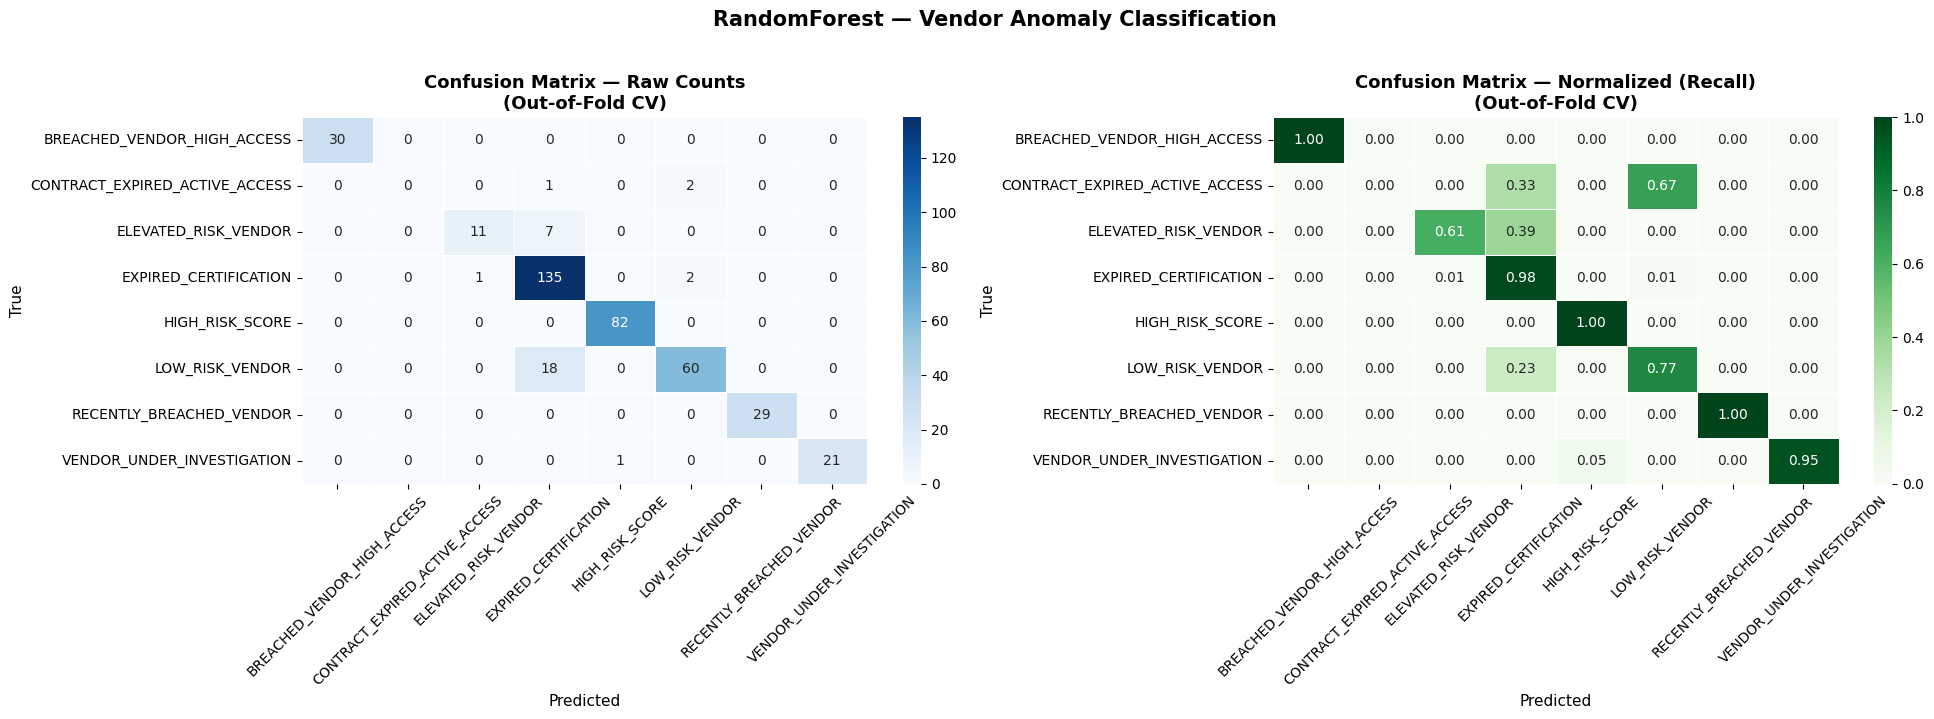

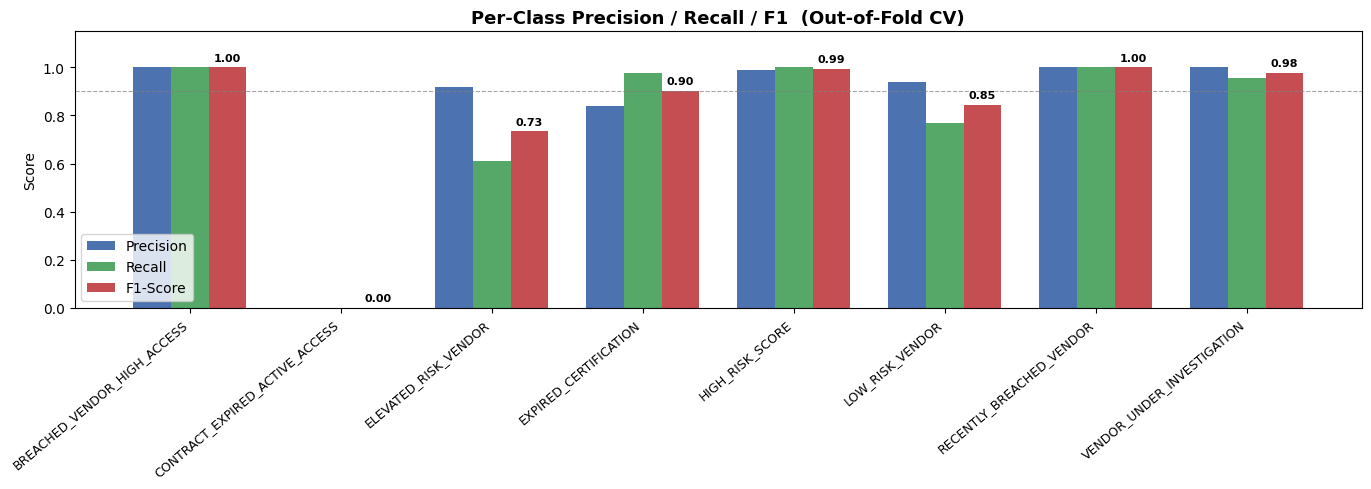


Out-of-Fold CV Accuracy: 92.00%
Note: CONTRACT_EXPIRED_ACTIVE_ACCESS has only 3 samples — treat its metrics with caution


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ── Use cross_val_predict for honest out-of-fold predictions ──────
# This gives confusion matrix on held-out data (not train data)
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_cv_pred = cross_val_predict(rf_final, X, y, cv=cv)

class_names = le.classes_

# ── 1. Classification Report ──────────────────────────────────────
print("Classification Report (Out-of-Fold CV Predictions):")
print("=" * 70)
print(classification_report(y, y_cv_pred, target_names=class_names, zero_division=0))

# ── 2. Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y, y_cv_pred)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix — Raw Counts\n(Out-of-Fold CV)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix — Normalized (Recall)\n(Out-of-Fold CV)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("RandomForest — Vendor Anomaly Classification", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Per-class bar chart ────────────────────────────────────────
report = classification_report(y, y_cv_pred, target_names=class_names,
                                output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.iloc[:-3]  # drop avg rows

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, report_df["precision"], width, label="Precision", color="#4C72B0")
bars2 = ax.bar(x,         report_df["recall"],    width, label="Recall",    color="#55A868")
bars3 = ax.bar(x + width, report_df["f1-score"],  width, label="F1-Score",  color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1  (Out-of-Fold CV)", fontsize=13, fontweight="bold")
ax.legend()
ax.axhline(y=0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="0.9 threshold")

# annotate f1 on top of each bar
for bar in bars3:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Summary ────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score
print(f"\nOut-of-Fold CV Accuracy: {accuracy_score(y, y_cv_pred):.2%}")
print(f"Note: CONTRACT_EXPIRED_ACTIVE_ACCESS has only 3 samples — treat its metrics with caution")

In [39]:
import joblib
import json
from datetime import datetime

# ── 1. Train final model on full data ────────────────────────────
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_final.fit(X, y)

# ── 2. Save model + label encoder + feature names ─────────────────
joblib.dump(rf_final, "vendor_anomaly_model.pkl")
joblib.dump(le,       "label_encoder.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

print("✓ Saved: vendor_anomaly_model.pkl")
print("✓ Saved: label_encoder.pkl")
print("✓ Saved: feature_names.pkl")

# ── 3. Print input spec ───────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║                        MODEL CARD                           ║
╠══════════════════════════════════════════════════════════════╣
║  Model    : RandomForestClassifier                          ║
║  Trees    : 100                                             ║
║  Classes  : 8                                               ║
║  CV Acc   : ~92%                                            ║
║  Saved    : vendor_anomaly_model.pkl                        ║
╚══════════════════════════════════════════════════════════════╝
""")

print("── RAW INPUT (from vendor_registry.csv) ─────────────────────")
raw_input_spec = {
    "vendor_id":                  "string       — e.g. VND00001",
    "vendor_name":                "string       — e.g. Enterprise Group",
    "vendor_type":                "categorical  — Cloud_Provider | Consulting | Contractor | Data_Provider | Hardware_Vendor | MSP | SaaS_Provider | Security_Vendor | Software_Vendor",
    "contact_name":               "string       — not used in model",
    "contact_email":              "string       — not used in model",
    "compliance_certifications":  "string       — pipe-separated with expiry: GDPR:2026-01-02|SOC2:2025-12-20",
    "data_access_scope":          "categorical  — Public_Data | Internal_Data | Customer_PII | Financial_Data | All_Systems",
    "risk_score":                 "integer      — 10 to 99",
    "breach_status":              "categorical  — No_Known_Breach | Historical_Breach | Recent_Breach_12mo | Under_Investigation",
    "annual_spend":               "integer      — e.g. 2725351",
    "contract_end_date":          "date string  — YYYY-MM-DD",
    "last_audit_date":            "date string  — YYYY-MM-DD",
}
for k, v in raw_input_spec.items():
    print(f"  {k:<30} {v}")

print("\n── ENGINEERED FEATURES (model actually sees these 34) ───────")
for i, feat in enumerate(X.columns):
    print(f"  {i+1:>2}. {feat}")

print("\n── OUTPUT ───────────────────────────────────────────────────")
print("  anomaly_type  (predicted class):")
for i, cls in enumerate(le.classes_):
    print(f"    {i} → {cls}")

# ── 4. Inference function ─────────────────────────────────────────
def predict_vendor(vendor_row_dict):
    """
    Input : dict with raw vendor fields (same as one row of vendor_registry.csv)
    Output: dict with anomaly_type, probability, all class probabilities
    
    Example:
        result = predict_vendor({
            "vendor_id":               "VND00000",
            "vendor_name":             "Enterprise Group",
            "vendor_type":             "Data_Provider",
            "compliance_certifications": "GDPR:2026-01-02|SOC2:2025-12-20",
            "data_access_scope":       "Public_Data",
            "risk_score":              12,
            "breach_status":           "No_Known_Breach",
            "annual_spend":            2725351,
            "contract_end_date":       "2027-12-13",
            "last_audit_date":         "2025-09-26",
        })
    """
    # load artifacts
    model    = joblib.load("vendor_anomaly_model.pkl")
    encoder  = joblib.load("label_encoder.pkl")
    feat_cols = joblib.load("feature_names.pkl")

    # build features from single row
    row_df   = pd.DataFrame([vendor_row_dict])
    X_input  = build_features(row_df)[feat_cols]

    # predict
    pred_idx  = model.predict(X_input)[0]
    pred_prob = model.predict_proba(X_input)[0]

    anomaly_type = encoder.inverse_transform([pred_idx])[0]
    confidence   = pred_prob[pred_idx]
    is_anomaly   = anomaly_type != "LOW_RISK_VENDOR"

    all_probs = {
        encoder.inverse_transform([i])[0]: round(float(p), 4)
        for i, p in enumerate(pred_prob)
    }

    return {
        "vendor_id":    vendor_row_dict.get("vendor_id", "unknown"),
        "vendor_name":  vendor_row_dict.get("vendor_name", "unknown"),
        "is_anomaly":   is_anomaly,
        "anomaly_type": anomaly_type,
        "confidence":   f"{confidence:.2%}",
        "all_probs":    all_probs
    }

# ── 5. Test inference on first vendor ────────────────────────────
sample = df.iloc[0].to_dict()
result = predict_vendor(sample)

print("\n── SAMPLE INFERENCE ─────────────────────────────────────────")
print(f"  Input vendor_id   : {result['vendor_id']}")
print(f"  Input vendor_name : {result['vendor_name']}")
print(f"  is_anomaly        : {result['is_anomaly']}")
print(f"  anomaly_type      : {result['anomaly_type']}")
print(f"  confidence        : {result['confidence']}")
print(f"\n  Class probabilities:")
for cls, prob in sorted(result["all_probs"].items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 30)
    print(f"    {cls:<35} {prob:.4f}  {bar}")

✓ Saved: vendor_anomaly_model.pkl
✓ Saved: label_encoder.pkl
✓ Saved: feature_names.pkl

╔══════════════════════════════════════════════════════════════╗
║                        MODEL CARD                           ║
╠══════════════════════════════════════════════════════════════╣
║  Model    : RandomForestClassifier                          ║
║  Trees    : 100                                             ║
║  Classes  : 8                                               ║
║  CV Acc   : ~92%                                            ║
║  Saved    : vendor_anomaly_model.pkl                        ║
╚══════════════════════════════════════════════════════════════╝

── RAW INPUT (from vendor_registry.csv) ─────────────────────
  vendor_id                      string       — e.g. VND00001
  vendor_name                    string       — e.g. Enterprise Group
  vendor_type                    categorical  — Cloud_Provider | Consulting | Contractor | Data_Provider | Hardware_Vendor | MSP | SaaS_P

KeyError: "['vtype_Hardware_Vendor', 'vtype_Cloud_Provider', 'vtype_MSP', 'vtype_Security_Vendor', 'vtype_Software_Vendor', 'vtype_Contractor', 'vtype_SaaS_Provider', 'vtype_Consulting'] not in index"

In [42]:
import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# ── 1. Simplified feature builder ────────────────────────────────
def build_features_simple(df):
    today = pd.Timestamp("today").normalize()
    out = pd.DataFrame()

    # breach status
    out["is_recent_breach"]       = (df["breach_status"] == "Recent_Breach_12mo").astype(int)
    out["is_under_investigation"]  = (df["breach_status"] == "Under_Investigation").astype(int)
    out["is_historical_breach"]   = (df["breach_status"] == "Historical_Breach").astype(int)

    # scope
    out["scope_high_sensitivity"] = df["data_access_scope"].isin(
        ["Customer_PII", "Financial_Data", "All_Systems"]).astype(int)
    out["scope_low_sensitivity"]  = df["data_access_scope"].isin(
        ["Internal_Data", "Public_Data"]).astype(int)

    # risk score
    out["risk_score"]    = df["risk_score"].astype(float)
    out["risk_high"]     = (df["risk_score"] >= 81).astype(int)
    out["risk_elevated"] = ((df["risk_score"] >= 66) & (df["risk_score"] <= 80)).astype(int)
    out["risk_low"]      = (df["risk_score"] <= 65).astype(int)

    # contract
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"]      = (contract_end - today).dt.days.fillna(9999)
    out["contract_expired"]        = (out["contract_days_left"] < 0).astype(int)
    out["contract_expired_severe"] = (out["contract_days_left"] < -70).astype(int)

    # audit
    last_audit = pd.to_datetime(df["last_audit_date"], errors="coerce")
    out["audit_days_since"] = (today - last_audit).dt.days.fillna(9999)

    # certifications
    def parse_certs(cert_str):
        expired, total = 0, 0
        if pd.isna(cert_str) or cert_str == "":
            return 0, 0, 0.0
        for cert in str(cert_str).split("|"):
            if ":" in cert:
                total += 1
                try:
                    if pd.to_datetime(cert.split(":")[1].strip()) < today:
                        expired += 1
                except:
                    pass
        pct = expired / total if total > 0 else 0.0
        return expired, total, pct

    parsed = df["compliance_certifications"].apply(parse_certs)
    out["expired_cert_count"] = parsed.apply(lambda x: x[0])
    out["total_cert_count"]   = parsed.apply(lambda x: x[1])
    out["pct_certs_expired"]  = parsed.apply(lambda x: x[2])
    out["has_expired_cert"]   = (out["expired_cert_count"] > 0).astype(int)
    out["all_certs_expired"]  = (
        (out["expired_cert_count"] == out["total_cert_count"]) &
        (out["total_cert_count"] > 0)
    ).astype(int)

    # spend
    out["annual_spend"] = df["annual_spend"].astype(float)

    return out


# ── 2. Train ──────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))

X = build_features_simple(merged)
le = LabelEncoder()
y = le.fit_transform(merged["anomaly_type"])

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X, y)
print(f"Train Accuracy: {rf.score(X, y):.2%}")
print(classification_report(y, rf.predict(X), target_names=le.classes_, zero_division=0))

# ── 3. Save ───────────────────────────────────────────────────────
joblib.dump(rf,              "vendor_anomaly_model.pkl")
joblib.dump(le,              "label_encoder.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")
print("✓ Model saved")

# ── 4. Predict function ───────────────────────────────────────────
def predict_vendor(vendor_dict):
    """
    INPUT  — raw vendor dict (one row from vendor_registry.csv)
    OUTPUT — anomaly prediction with confidence
    """
    model     = joblib.load("vendor_anomaly_model.pkl")
    encoder   = joblib.load("label_encoder.pkl")
    feat_cols = joblib.load("feature_names.pkl")

    row_df  = pd.DataFrame([vendor_dict])
    X_input = build_features_simple(row_df)[feat_cols]

    pred_idx  = model.predict(X_input)[0]
    pred_prob = model.predict_proba(X_input)[0]
    anomaly_type = encoder.inverse_transform([pred_idx])[0]

    return {
        "vendor_id":    vendor_dict.get("vendor_id"),
        "vendor_name":  vendor_dict.get("vendor_name"),
        "is_anomaly":   anomaly_type != "LOW_RISK_VENDOR",
        "anomaly_type": anomaly_type,
        "confidence":   f"{pred_prob[pred_idx]:.2%}",
        "all_probs":    {
            encoder.inverse_transform([i])[0]: round(float(p), 4)
            for i, p in enumerate(pred_prob)
        }
    }

# ── 5. Test on first vendor ───────────────────────────────────────
result = predict_vendor(df.iloc[0].to_dict())

print("\nINPUT:")
for k in ["vendor_id", "vendor_name", "breach_status",
          "data_access_scope", "risk_score", "contract_end_date",
          "compliance_certifications"]:
    print(f"  {k:<30}: {df.iloc[0][k]}")

print("\nOUTPUT:")
print(f"  is_anomaly   : {result['is_anomaly']}")
print(f"  anomaly_type : {result['anomaly_type']}")
print(f"  confidence   : {result['confidence']}")
print("\n  All class probabilities:")
for cls, prob in sorted(result["all_probs"].items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 40)
    print(f"  {cls:<35} {prob:.4f}  {bar}")

Train Accuracy: 100.00%
                                precision    recall  f1-score   support

   BREACHED_VENDOR_HIGH_ACCESS       1.00      1.00      1.00        30
CONTRACT_EXPIRED_ACTIVE_ACCESS       1.00      1.00      1.00         3
          ELEVATED_RISK_VENDOR       1.00      1.00      1.00        18
         EXPIRED_CERTIFICATION       1.00      1.00      1.00       138
               HIGH_RISK_SCORE       1.00      1.00      1.00        82
               LOW_RISK_VENDOR       1.00      1.00      1.00        78
      RECENTLY_BREACHED_VENDOR       1.00      1.00      1.00        29
    VENDOR_UNDER_INVESTIGATION       1.00      1.00      1.00        22

                      accuracy                           1.00       400
                     macro avg       1.00      1.00      1.00       400
                  weighted avg       1.00      1.00      1.00       400

✓ Model saved

INPUT:
  vendor_id                     : VND00000
  vendor_name                   : Enterprise

In [43]:
df.columns

Index(['vendor_id', 'vendor_name', 'vendor_type', 'contact_name',
       'contact_email', 'compliance_certifications', 'data_access_scope',
       'risk_score', 'breach_status', 'annual_spend', 'contract_end_date',
       'last_audit_date'],
      dtype='object')